# Hernquist distribution
The aim of this notebook is to generate an unperturbed Hernquist distribution. We will then add two extra points which will simulate two black holes, to study the dynamical friction and their interaction.

The Henrquist profile is described by the follwing density distribution:

$$ \rho(r) = \frac{M}{2\pi}\frac{a}{r}\frac{1}{(r+a)^3} $$   
where $a$ is a scale radius. Note that for radii larger than $a$, the density goes as $r^{-4}$, at smaller radii it will instead go as r.

From the density distribution one can compute the mass distribution and the potential shape, assuming a spherical distribution. 

$$ M(R) = \int_0^R 4\pi r^2 \rho(r) dr  = \frac{M_{tot}R^2}{(R+a)^2}$$

$$ \phi_H (R) = -4\pi G\Bigl[\frac{1}{R} \int_0^R \rho(r) r^2 dr + \int_R^\infty \rho(r) r dr\Bigr] = - \frac{GM}{(R+a)}$$

In [1]:
#pip install scienceplots

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

import scienceplots
plt.style.use(['science', 'no-latex'])

## Initialization

In [3]:
n = 10000 #number of particles
a = 10 #scale radius
M = 1 #each particle has a mass = M/n in internal units
n_dim = 3

## Position sampling
In order to create the profile, we need to sample the position and velociy of each of our n particles. To do this, we first find the radial distribution:

$$ P(R) = \frac{M(R)}{M_{tot}} = \frac{R^2}{(R + a)^2} $$

where $0 < P(R) < 1$. In this way we can sample from a uniform distribution and then convert that value into a radius:

$$ R = \frac{a\sqrt{P(R)}}{1-\sqrt{P(R)}}$$

Assuming spherical symmetry, the angular positions can instead be generated from:


$$ \Theta = \arccos{(1-2P(\Theta))}$$

$$ \Phi = {2\pi}P(\Phi)$$

where P once again is drawn from a uniform distribution.

In [4]:
def radius_from_P (P):
    return (a * np.sqrt(P)) / (1 - np.sqrt(P))

In [5]:
#samples ---------------------------------
P_R = np.random.uniform(0, 1, n)
radius = radius_from_P (P_R)
radius_s = np.sort(radius)
r_inverse = radius_s[::-1] #we will need the arr that goes from rmax to rmin later

P_theta = np.random.uniform(0, 1, n)
theta = np.arccos(1 - 2*P_theta)

P_phi = np.random.uniform(0, 1, n)
phi = 2 * np.pi * P_phi

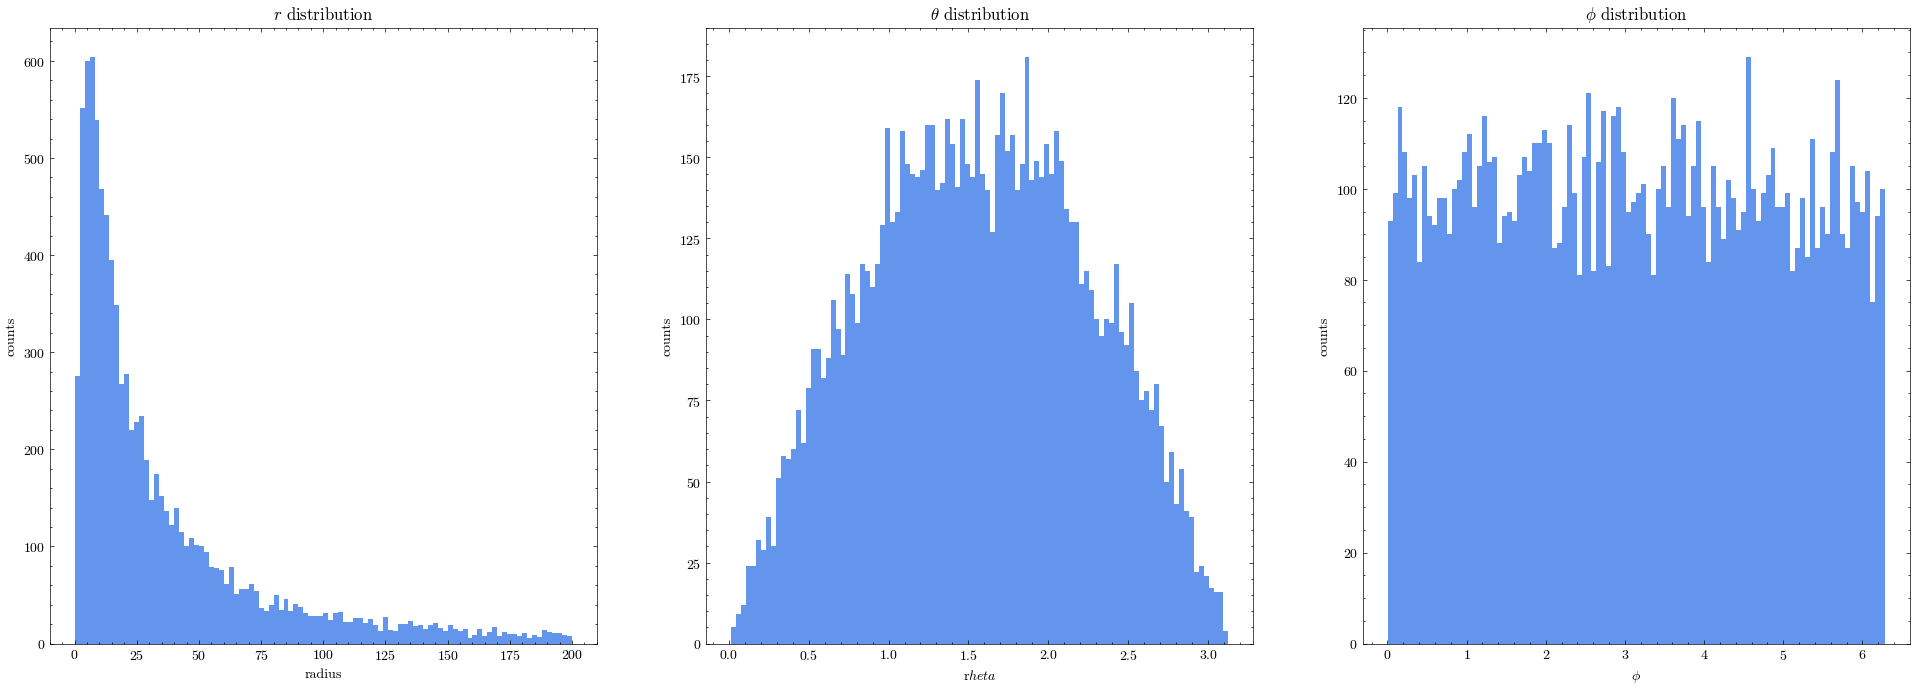

In [6]:
fig,ax = plt.subplots(ncols=3,nrows=1,figsize=(24,8))
ax[0].hist(r_inverse, range=(0,200), bins = 100, color = 'cornflowerblue')
ax[0].set(title = '$r$ distribution', ylabel = "counts", xlabel = "radius")

ax[1].hist(theta, bins = int(np.sqrt(n)), color = 'cornflowerblue')
ax[1].set(title = r'$\theta$ distribution', ylabel = "counts", xlabel = 'r$\theta$')
ax[1].plot()

ax[2].hist(phi, bins = int(np.sqrt(n)), color = 'cornflowerblue')
ax[2].set(title = '$\phi$ distribution', ylabel = "counts", xlabel = "$\phi$")
ax[2].plot()

plt.show()

In [7]:
#carthesian coord conversion -----------
def sph_to_carth (radius, theta, phi):
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return x, y, z

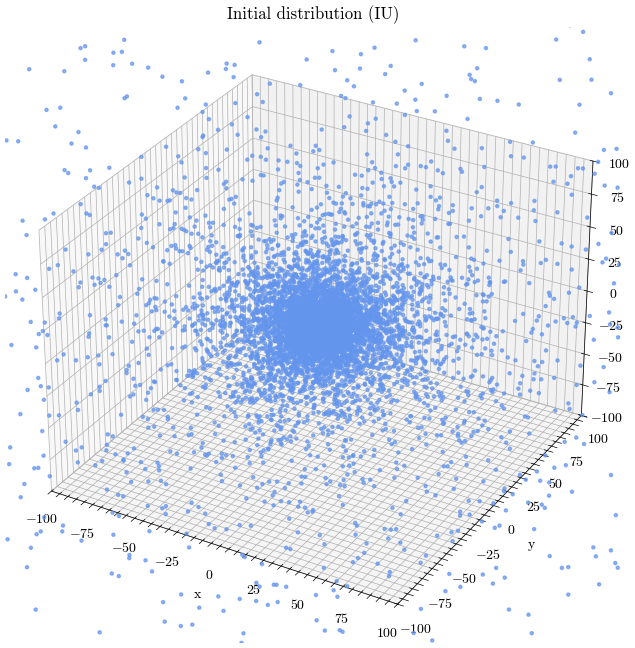

In [8]:
x, y, z = sph_to_carth(radius, theta, phi)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(x,y,z,s=5,alpha=0.7, color = 'cornflowerblue')
ax.set (title = 'Initial distribution (IU)', xlabel = 'x', ylabel = 'y', zlabel = 'z', xlim = (-100,100), ylim = (-100, 100), zlim = (-100, 100))

plt.show()

## Velocity sampling
To sample our velocities, we first need to compute the distribution function $f$ through the Eddington formula:
$$ f(\varepsilon) = \frac{1}{\sqrt{8}\pi^2} \frac{d}{d\varepsilon}\int_0^{\varepsilon} \frac{d\rho}{d\psi}\frac{1}{\sqrt{\psi-\varepsilon}} d\psi$$

where $\psi = -\phi$.

The extreme of integration is different for each particle:
$$\varepsilon = \psi - \frac{v^2}{2} $$

$\varepsilon$ is between 0 and the maximum of the potential energy.

In [18]:
def compute_pot(R):
    return - M / (R + a)

def compute_rho(R):
    return M / (2* np.pi) * a/R * 1/(R+a)**3

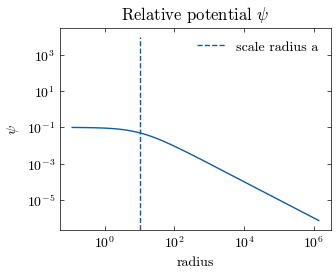

In [19]:
potential = - compute_pot (r_inverse)
#we have the potential of each particle, which also corresponds to their eps_max

plt.plot(r_inverse, potential)
plt.title("Relative potential $\psi$")
plt.ylabel("$\psi$")
plt.xlabel("radius")
plt.vlines(a, ymin = 0, ymax = 1e4, linestyle = "dashed", label = "scale radius a")
plt.legend()
plt.loglog()
plt.show()


So the relative potential seems to have to correct trend (constant when r << a, prop to $r^{-1}$ when r>> a) and it is positive. I now want to check at each value of the potential which is the maximum value of velocity $v$: if I know that $\epsilon > 0$ for a bound system and that $\epsilon = \psi + \frac{v^2}{2}$, i should be able to get velocity ranges.

$$ \frac{v^2}{2} < \psi $$
$$ -\sqrt{2\psi} < v < \sqrt{2\psi} $$

and since obviously v is a physical velocity this then becomes:

$$ 0 < v < \sqrt{2\psi} $$

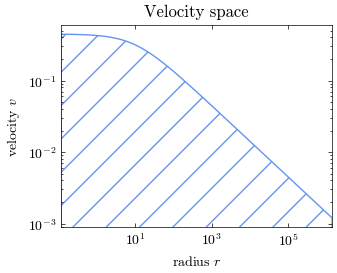

min radius =  0.1156857701391117  , max velocity =  0.4446490131375258


In [20]:
max_vel = np.sqrt(2 * potential)
plt.fill_between(r_inverse, y1 = 0, y2 = max_vel, fc = "white", edgecolor = "cornflowerblue",  hatch = "/")
plt.xlim([r_inverse[n-1], r_inverse[0]])
plt.title("Velocity space")
plt.xlabel("radius $r$")
plt.ylabel("velocity $v$")
plt.loglog()
plt.show()

print("min radius = ", r_inverse[n-1],  " , max velocity = " , max_vel[n-1])

Let's plot $\epsilon$, its value at each radius will be constrained by the value of the min (0) and max velocity that we've just found.
Actually not needed, as $\epsilon$ is maximised for $v = 0$, for which $\epsilon = \psi$ and for the maximum velocity it will be null.


Since we computed the potential on the r array which goes from $r_{max}$ to $r_{min}$, the potential array is already in ascending order.

## Some comments on $\epsilon$ and the integration
We said that $\epsilon = \psi - v^2 / 2$. For our samples, we now have the potential at each radius -> what we are missing to integrate the Eddington's formula is the values of $\epsilon$ for each particle, which we obviously don't have as they require knowing the velocity. 
$$ f(\epsilon) \propto \frac{dI}{d\epsilon} $$
But knowing the definition of $\epsilon$ and knowing that it must be positive has given us a constrain on the possible values of the velocity: now $\epsilon$ has to run between 0 (when the velocity is maximum and equal to $\sqrt{2\psi}$)  and the potential $\psi$ of the radius we've evaluating. Basically, we first choose one value of epsilon, this will then correspond not to a single radius, but to an array of them, given by the condition:
$$0 < r < r (\psi = \epsilon)$$

At $r = 0$ $v = \sqrt{\psi - \epsilon}$,  while at $r (\psi = \epsilon)$, $v = 0$.

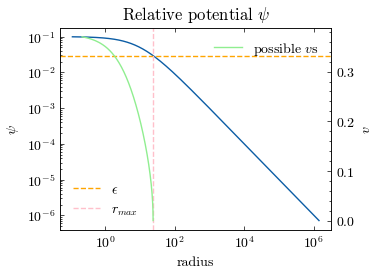

In [21]:
fig, ax1 = plt.subplots()

ex= int(n/2)
eps_ex = potential[ex]
ax2 = ax1.twinx()
ax1.loglog()
ax2.semilogx()
ax1.plot(r_inverse, potential)
ax1.set(title = "Relative potential $\psi$", ylabel = "$\psi$", xlabel = "radius")
ax1.axhline(eps_ex, linestyle = "dashed", c = "orange", label = "$\epsilon$")
ax1.axvline(r_inverse[ex],  linestyle = "dashed", c = "pink", label = "$r_{max}$")

ax2.plot(r_inverse[ex:(n-1)], np.sqrt(2 * (potential[ex:(n-1)] - eps_ex)), color = 'lightgreen',label = 'possible $v$s')
ax2.set_ylabel("$v$")

ax1.legend()
ax2.legend()
plt.show()

So we will need to compute the integral for each value of $\epsilon$, for which the relative potential runs from $\psi(r_{max})$ to $\psi(r = 0)$.

In [22]:
eps = potential 
integral = np.zeros(n)
n_points = 100
alpha = 0.999999999 #or else we are dividing by zero in the integral
for i in range(n):
    r = np.linspace(r_inverse[0]+1, r_inverse[i], n_points)
    psi = - compute_pot(r)
    rho = compute_rho(r)
    drho_dpsi = np.gradient(rho, psi)
    for j in range(n_points):
        #if psi[j] - eps[i] == 0: print("errore integrale", i, j)
        if np.gradient(psi)[j] == 0: print("errore gradiente", i, psi[j])
            
    integral[i] = np.trapz(drho_dpsi *( 1/np.sqrt(eps[i] - alpha*psi)), psi)

/tmp/ipykernel_1181/2658520684.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral[i] = np.trapz(drho_dpsi *( 1/np.sqrt(eps[i] - alpha*psi)), psi)


In [23]:
print(integral)

[3.28626679e-24 3.23983528e-18 3.41669079e-16 ... 2.85378975e+02
 3.43691817e+02 6.68377597e+02]


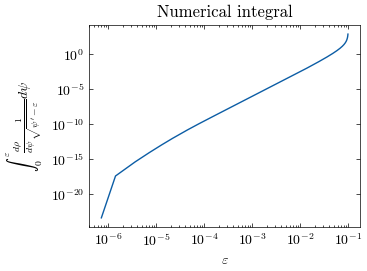

In [24]:
fig = plt.figure()

plt.plot(eps,integral)
plt.loglog()
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r"$\int_0^{\varepsilon} \frac{d\rho}{d\psi}\frac{1}{\sqrt{\psi'-\varepsilon}} d\psi$")

plt.title('Numerical integral')
plt.show()

And now our Eddington formula will be given by deriving the integral $I$ for $\varepsilon$ and multiplying it by $1/{\sqrt{8}\pi^2}$

In [25]:
di_deps = np.gradient(integral, eps)
edd_f = di_deps * 1/(np.pi**2 * np.sqrt(8))

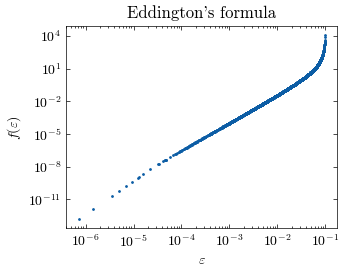

In [26]:
plt.scatter(eps, edd_f, s= 1)
plt.title("Eddington's formula")
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'$f(\varepsilon)$')
plt.loglog()
plt.show()

In [27]:
from scipy.interpolate import PchipInterpolator

eps_new = np.linspace(np.min(eps), np.max(eps), n)
interp_f = PchipInterpolator(eps, edd_f)

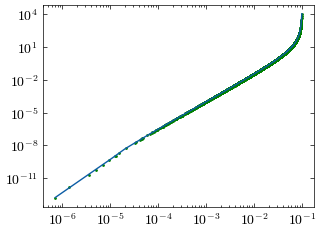

In [28]:
plt.plot(eps_new, interp_f(eps_new))
plt.scatter(eps, edd_f, s = 1, c = 'g')
plt.loglog()
plt.show()

In [29]:
from tqdm import tqdm

/tmp/ipykernel_1181/1781625262.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  F_eps[j] = np.trapz(4 * np.pi * np.sqrt(2 * (pot_i - eps_i)) * f_eps, eps_i)


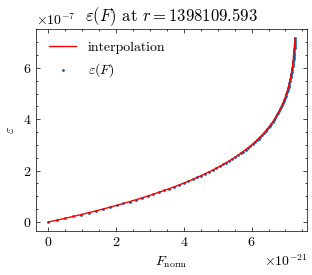

100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:12<00:00, 792.24it/s]


In [32]:
v_particles = np.zeros(n)

for i in tqdm(range(n)):
    pot_i = potential[i]
    eps_max_i = np.linspace(0, pot_i, n_points) #<- given a potential epsilon is within 0 and pot
    #print(eps_max_i)
    #for each particle we create the integral over epsilon
    #interpolate it to have a distribution
    #then given a sampled value we get the corresponding epsilon
    #since psi is fixed, having epsilon gives us the value of the velocity
    
    F_eps = np.zeros(n_points) 

    for j in range(n_points):
        eps_i = np.copy(eps_max_i[0:(j+1)]) #creating the epsilon array over which we integrate
        #print(eps_i)
        f_eps = interp_f(eps_i) #evaluating f(eps) over the array
        #print(f_eps)
        F_eps[j] = np.trapz(4 * np.pi * np.sqrt(2 * (pot_i - eps_i)) * f_eps, eps_i)
        #print(F_eps)

    #F_eps_norm = F_eps / max(F_eps) #normalizing the distribution
    interp_eps_F = scipy.interpolate.interp1d(F_eps, eps_max_i, kind='linear')

    if i == 0:
        xx = np.linspace(0, max(F_eps), n_points)
        plt.plot(xx, interp_eps_F(xx), label = 'interpolation', c = 'r')
        plt.scatter(F_eps, eps_max_i, s = 1, label = r'$\varepsilon(F)$')
        plt.ylabel(r'$\varepsilon$')
        plt.xlabel(r'$F_\mathrm{norm}$')
        plt.title(r'$\varepsilon(F)$ at $r = $' + str('%.3f'%r_inverse[i]))
        plt.legend()
        plt.show()

    F_sample = np.random.uniform(0, max(F_eps))
    eps_sample = interp_eps_F(F_sample)
    v_particles[i] = np.sqrt(2 * (pot_i - eps_sample))

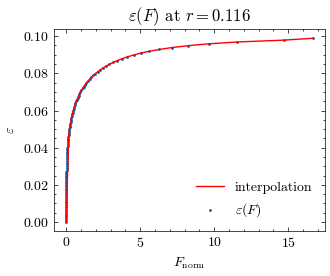

In [34]:
xx = np.linspace(0, max(F_eps), n_points)
plt.plot(xx, interp_eps_F(xx), label = 'interpolation', c = 'r')
plt.scatter(F_eps, eps_max_i, s = 1, label = r'$\varepsilon(F)$')
plt.ylabel(r'$\varepsilon$')
plt.xlabel(r'$F_\mathrm{norm}$')
plt.title(r'$\varepsilon(F)$ at $r = $' + str('%.3f'%r_inverse[i]))
plt.legend()
plt.show()

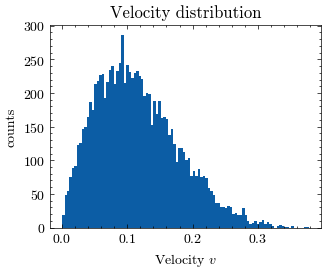

In [35]:
plt.figure()
plt.hist(v_particles, bins = 100)
plt.xlabel("Velocity $v$")
plt.ylabel("counts")
plt.title("Velocity distribution")
plt.show()


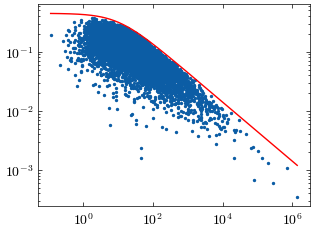

In [36]:
plt.plot(r_inverse, np.sqrt(2 * potential), c = 'r')
plt.scatter(r_inverse, v_particles, s = 2)
plt.loglog()
plt.show()

In [37]:
P_theta_v = np.random.uniform(0, 1, n)
theta_v = np.arccos(1 - 2*P_theta_v)

P_phi_v = np.random.uniform(0, 1, n)
phi_v = 2 * np.pi * P_phi_v

vx, vy, vz = sph_to_carth (v_particles, theta_v, phi_v)
print(vx)

[ 3.20047321e-04 -9.78942611e-04 -1.33705503e-04 ...  3.03445097e-02
  2.15708353e-02  1.42684793e-01]


In [38]:
inputf = open('Hernquist_in.txt', 'w')

particles_masses = ''
particles_positions = ''
particles_velocities = ''

for i in range(n):
    particles_masses = particles_masses + str(M/n) + '\n'
    particles_positions = particles_positions + str(x[i]) + ' ' + str(y[i]) + ' ' + str(z[i]) + '\n'
    particles_velocities = particles_velocities +  str(vx[i]) + ' ' + str(vy[i]) + ' ' + str(vz[i]) + '\n'

lines = [str(n) + '\n' + str(n_dim) + '\n0\n' + particles_masses + particles_positions + particles_velocities]
inputf.writelines(lines)

inputf.close()

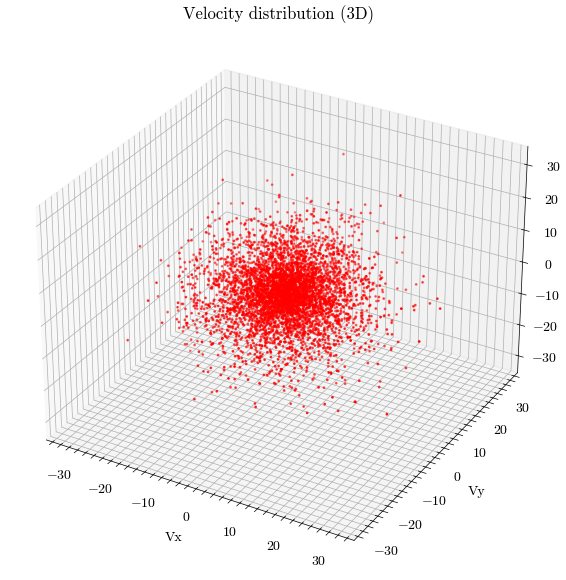

In [32]:
fig_vel_scatter = plt.figure(figsize=(8, 6))
ax_vel_scatter = fig_vel_scatter.add_subplot(111, projection='3d')

ax_vel_scatter.scatter(vx, vy, vz, s=1, c='red')
ax_vel_scatter.set_title("Velocity distribution (3D)")
ax_vel_scatter.set_xlabel("Vx")
ax_vel_scatter.set_ylabel("Vy")
ax_vel_scatter.set_zlabel("Vz")

vlim = max(np.max(np.abs(vx)), np.max(np.abs(vy)), np.max(np.abs(vz)))
ax_vel_scatter.set_xlim(-vlim, vlim)
ax_vel_scatter.set_ylim(-vlim, vlim)
ax_vel_scatter.set_zlim(-vlim, vlim)

plt.tight_layout()
plt.show()

In [33]:
vx_mean = np.mean(vx)
vy_mean = np.mean(vy)
vz_mean = np.mean(vz)

vx_disp = np.std(vx)
vy_disp = np.std(vy)
vz_disp = np.std(vz)

v_mod = np.sqrt(vx**2 + vy**2 + vz**2)
v_mod_mean = np.mean(v_mod)
v_mod_disp = np.std(v_mod)

C:\Users\lm101\AppData\Local\Temp\ipykernel_6012\3349980600.py:18: UserWarning: Glyph 956 (\N{GREEK SMALL LETTER MU}) missing from current font.
  plt.tight_layout()
C:\Users\lm101\AppData\Local\Temp\ipykernel_6012\3349980600.py:18: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from current font.
  plt.tight_layout()
C:\Users\lm101\anaconda3\envs\astro_env\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 956 (\N{GREEK SMALL LETTER MU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lm101\anaconda3\envs\astro_env\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


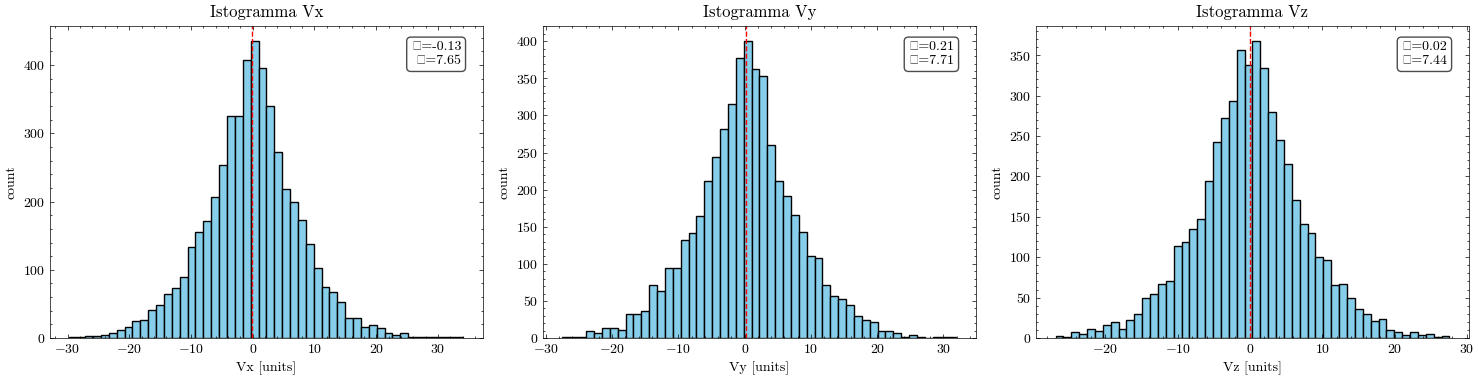

In [34]:
fig_hist, axs = plt.subplots(1, 3, figsize=(15, 4))

components = {'Vx': vx, 'Vy': vy, 'Vz': vz}

for i, (label, data) in enumerate(components.items()):
    axs[i].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=1)
    axs[i].set_title(f'Istogramma {label}')
    axs[i].set_xlabel(f'{label} [units]')
    axs[i].set_ylabel('count')
    
    mean = np.mean(data)
    std = np.std(data)
    axs[i].axvline(mean, color='red', linestyle='dashed')
    axs[i].text(0.95, 0.95, f'μ={mean:.2f}\nσ={std:.2f}', 
                transform=axs[i].transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()


 .\treecode in=Hernquist_in.txt out=Hernquist_out.txt dtime=0.002 eps=0.0767 theta=0.05 tstop=10 dtout=0.1 > Hernquist_log.txt

In [156]:
epsilon = a / np.sqrt(n)

In [157]:
epsilon

np.float64(0.1)

In [160]:
sphere_density = compute_rho(a)
print('\nSphere density = ', sphere_density)

dyn_time = np.sqrt((3 * np.pi)/(16 *sphere_density))
print('\nDynamical time = ', dyn_time)

collapse_time = dyn_time * np.power(2, -1/2)

print('\nCollapse time = ', collapse_time)


Sphere density =  1.989436788648692e-05

Dynamical time =  172.0721162863643

Collapse time =  121.67336027920837
